## Sesión 6 — Visualización de Datos II
### Cliente: Superbock Group — Miguel Santos
#### Objetivo: Gráficos para presentación al consejo directivo

In [84]:
# importar librerias necesarias para el analisis
# Pandas / Matplotlib.pyplot
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('C:\\Users\\crist\\Proyectos_pyhon\\train.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [85]:
    # Tenemos 12 Columnas / 891 datos 
    # limpieza de de Age / Embarked
    # Usamos la mediana para reemplazar los valores faltades de Age(edad) con el fin de poder realizar un analisis
    # Usamos la Moda para la variable Embarked 
   
df['Age']= df['Age'].fillna(df['Age'].median())
df['Embarked']= df['Embarked'].fillna(df['Embarked'].mode()[0])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [88]:
# Distribucion por grupos de edades
# porcentaje de cada grupo 
menores = df[df['Age']<= 17]['Age'].count()
jovenes = df[(df['Age']> 17) & (df['Age'] <= 34)] ['Age'].count()
mayores =df[df['Age']> 34] ['Age'].count()
print(menores,jovenes,mayores)
total = df['Age'].count()
print(f'Menores: {menores/total*100:.1f}%')
print(f'Jovenes: {jovenes/total*100:.1f}%')
print(f'Mayores: {mayores/total*100:.1f}%')

113 542 236
Menores: 12.7%
Jovenes: 60.8%
Mayores: 26.5%


In [89]:
# Se confirma que los valores anteriores por grupos 
#corresponden al valor total
print(df['Age'].count())
print(113 + 542 + 236)

891
891


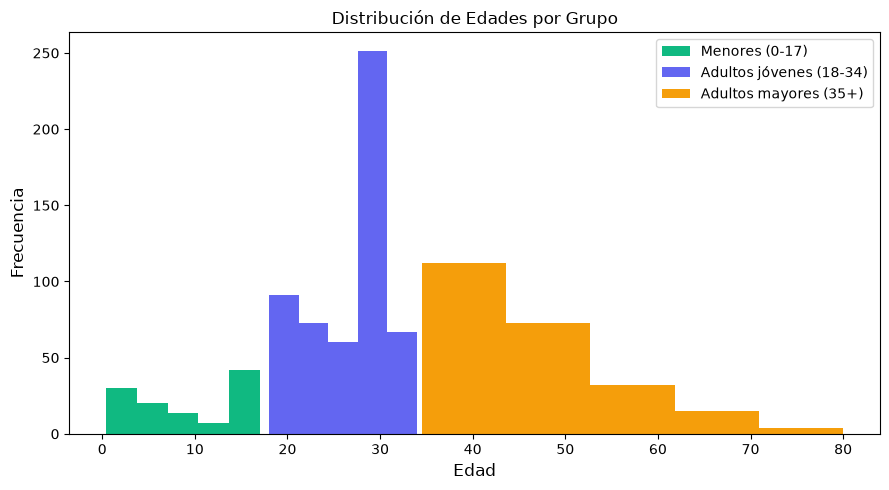

In [ ]:
# tipo de histogramada por grupo de edades
plt.figure(figsize=(9, 5))
plt.hist(df[df['Age'] <= 17]['Age'], bins=5, color='#10b981', label='Menores (0-17)')
plt.hist(df[(df['Age'] > 17) & (df['Age'] <= 34)]['Age'], bins=5, color='#6366f1', label='Adultos jóvenes (18-34)')
plt.hist(df[df['Age'] > 34]['Age'], bins=5, color='#f59e0b', label='Adultos mayores (35+)')

plt.title('Distribución de Edades por Grupo')
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

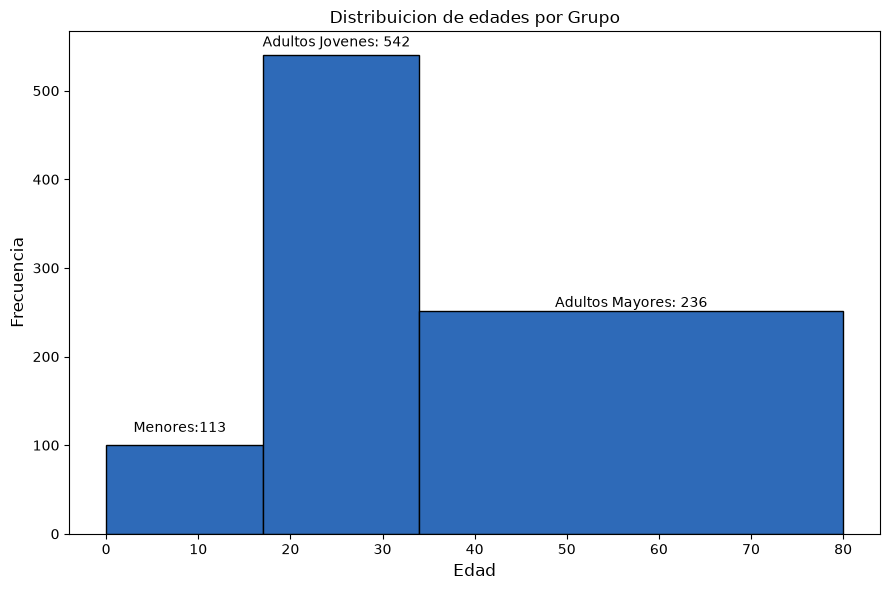

In [87]:

# Distribución de Edades por Grupo
plt.figure(figsize=(9, 6))
plt.hist(df['Age'], color="#2e6ab8", edgecolor='black', bins= [0 , 17, 34  ,80])
plt.title('Distribuicion de edades por Grupo')
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.text(8, 113 + 2, 'Menores:113', ha= 'center')
plt.text(25, 542 + 8, 'Adultos Jovenes: 542', ha= 'center')
plt.text(57, 236 + 20, 'Adultos Mayores: 236', ha= 'center')
plt.tight_layout()
plt.show()

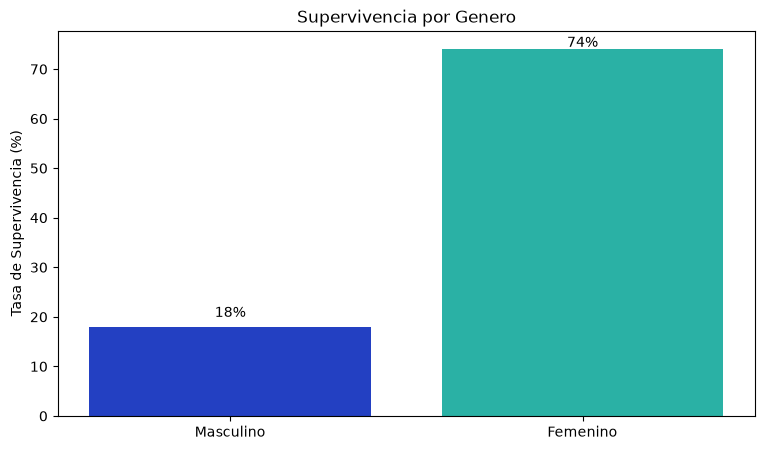

In [90]:
#Distribuicion de supervivencia por genero 

categorias = ['Masculino' , 'Femenino']
valores = [18, 74]
colores = ["#2340c2", "#2AB1A5"]
plt.figure(figsize=(9, 5))
plt.bar( categorias, valores, color=colores)
plt.title('Supervivencia por Genero')
plt.ylabel('Tasa de Supervivencia (%)')
plt.text(0, 18 + 2, '18%', ha= 'center')
plt.text(1, 74 + 0.5, '74%', ha= 'center')
plt.show()

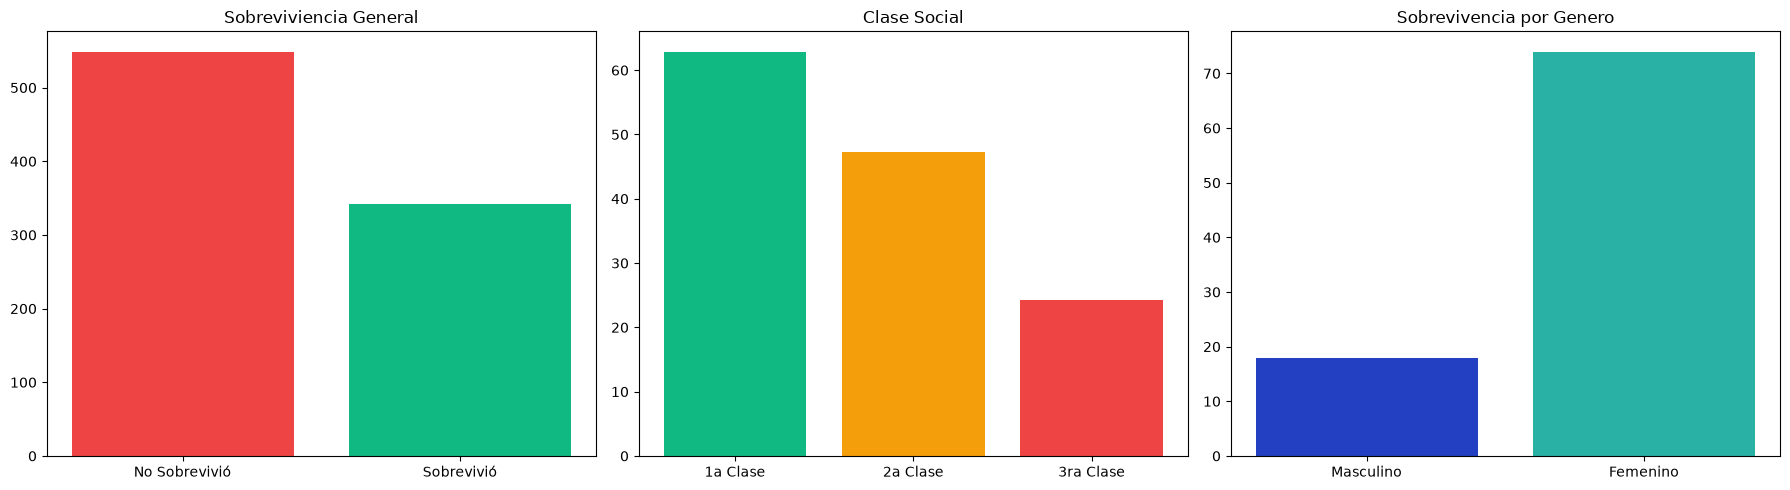

In [91]:
# Graficos en una sola imagen()
# Supervivencia General 
# Clase Social (clase de billete)
# Supervivencia por Genero 
fig,( ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (18, 5))
categorias1 = ['No Sobrevivió', 'Sobrevivió']
valores1 = [549, 342]
colores1 = ['#ef4444', '#10b981']

ax1.bar(categorias1, valores1,color=colores1)
ax1.set_title('Sobreviviencia General') 

categorias2 = ['1a Clase', '2a Clase', '3ra Clase']
valores2 = [62.9 , 47.3, 24.2]
colores2 = ['#10b981', '#f59e0b', '#ef4444']
ax2.bar(categorias2, valores2, color=colores2)
ax2.set_title('Clase Social')

categorias3 = ['Masculino' , 'Femenino']
valores3 = [18, 74]
colores3 = ["#2340c2", "#2AB1A5"]
ax3.bar(categorias3, valores3, color=colores3)
ax3.set_title('Sobrevivencia por Genero')
plt.tight_layout()
plt.show()